<a href="https://colab.research.google.com/github/cavalcantiju/proj1.1_DS_vendacasas/blob/main/proj1_DS_vendacasas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd

dados = pd.read_csv("/content/Preços_de_casas.csv")
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [48]:
dados = dados.drop(columns = "Id")

In [49]:
dados.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,79.5224,1,79.3366,2,548,0,1027905.0
1,117.2398,0,0.0000,2,460,0,894795.0
2,85.4680,1,80.4514,2,608,0,1101855.0
3,89.2769,1,70.2324,1,642,0,690200.0
4,106.3705,1,97.8237,2,836,0,1232500.0


In [50]:
#quais fatores tão relacionados ao preço da casa? o coeficiente de correlação
#mede a relaçao entre as var. 1: corr positiva perfeita: uma var aumenta a
#outra tb. 0 = sem relacao. -1: corr negatv pfta: uma var aumenta a outra diminui

corr = dados.corr()

In [51]:
corr["preco_de_venda"]

,preco_de_venda
area_primeiro_andar,0.616557
existe_segundo_andar,0.138541
area_segundo_andar,0.305311
quantidade_banheiros,0.563132
capacidade_carros_garagem,0.640214
qualidade_da_cozinha_Excelente,0.496223
preco_de_venda,1.000000


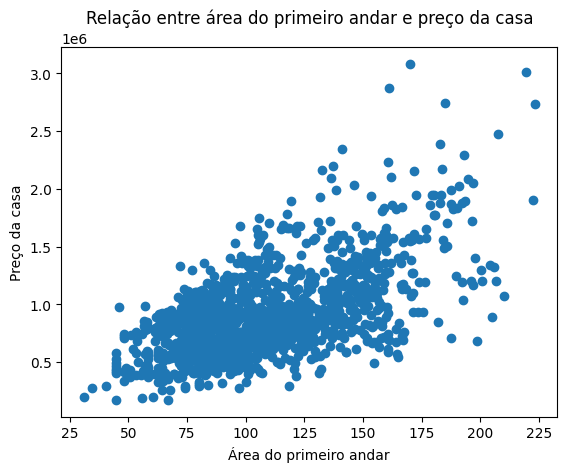

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.scatter(dados["area_primeiro_andar"], dados["preco_de_venda"])
plt.title("Relação entre área do primeiro andar e preço da casa")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço da casa")
plt.show()

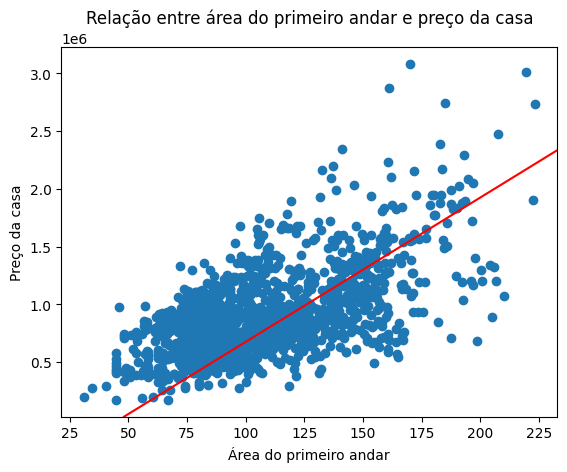

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.scatter(dados["area_primeiro_andar"], dados["preco_de_venda"])
plt.axline(xy1 = (66, 250000), xy2 = (190, 1800000), color = 'red')
plt.title("Relação entre área do primeiro andar e preço da casa")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço da casa")
plt.show()

In [54]:
#QUAL A MELHOR RETA?
px.scatter(dados, x = "area_primeiro_andar", y = "preco_de_venda", trendline_color_override= "red", trendline = 'ols')

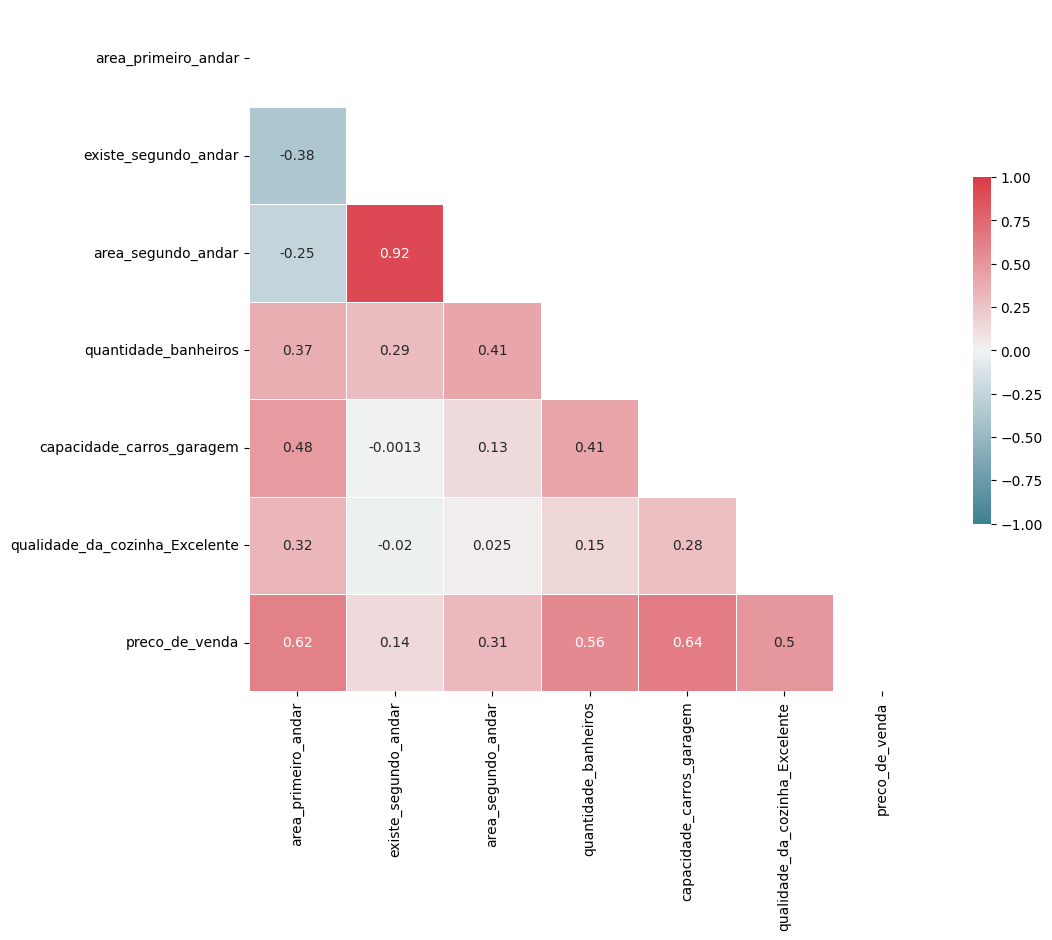

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()

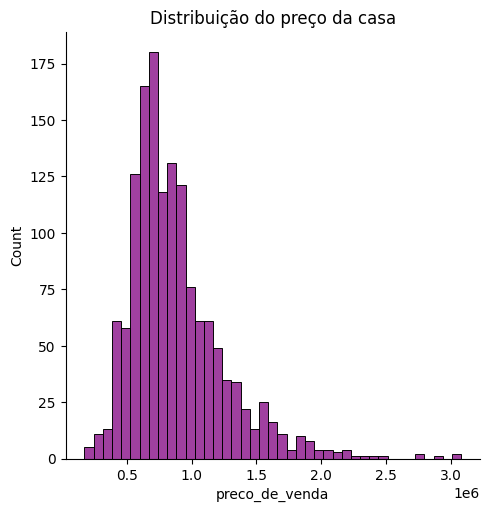

In [56]:

sns.displot(dados["preco_de_venda"], color = 'purple')
plt.title("Distribuição do preço da casa")
plt.show()

In [57]:
from sklearn.model_selection import train_test_split
y = dados['preco_de_venda']
x = dados.drop(columns = 'preco_de_venda')
x.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente
0,79.5224,1,79.3366,2,548,0
1,117.2398,0,0.0000,2,460,0
2,85.4680,1,80.4514,2,608,0
3,89.2769,1,70.2324,1,642,0
4,106.3705,1,97.8237,2,836,0


In [58]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state= 230)
df_train = pd.DataFrame(data = X_train)
df_train['preco_de_venda'] = y_train

df_train.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
1303,65.7732,0,0.0000,1,0,0,406725.0
326,55.3684,1,55.3684,1,189,0,384540.0
386,74.6916,1,107.4853,2,560,0,1059950.0
615,103.6764,0,0.0000,1,440,0,788800.0
236,94.2006,1,67.8170,2,457,0,958885.0


In [59]:
from statsmodels.formula.api import ols
modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data = df_train).fit()
modelo_0.params

,0
Intercept,152909.288334
area_primeiro_andar,6793.641641


## Interpretação do Modelo de Regressão

O modelo estimado foi:

preco_de_venda = 152909.29 + 6793.64 * area_primeiro_andar

### Intercepto (152.909,29)

Representa o preço estimado quando a área do primeiro andar é igual a zero.  
Embora não tenha interpretação prática real, ele posiciona a reta de regressão.

### Coeficiente da área (6.793,64)

Indica que, para cada aumento de 1 unidade em `area_primeiro_andar`,  
o preço do imóvel aumenta, em média, R$ 6.793,64.

Ou seja, quanto maior a área do primeiro andar, maior tende a ser o preço do imóvel.

In [60]:
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          2.22e-105
Time:                        15:16:15   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

🔹 1️⃣ R² = 0.377 (COEFICIENTE DE DETERMINAÇÃO)

Significa que:

37,7% da variação do preço de venda é explicada pela variável area_primeiro_andar. uNS 62% vai ser explicado por outros fatores como banheiro, outras coisas q nao seja area do primeiro andar

Modelo de Regressão Linear

A forma geral da regressão linear simples é:

$$
Y = \beta_0 + \beta_1 X + e
$$

Onde:

- **Y** → Variável resposta (dependente).
- **β₀** → Intercepto (valor de Y quando X = 0).
- **β₁** → Coeficiente angular (impacto de X sobre Y).
- **X** → Variável explicativa (independente).
- **e** → Erro residual.


Equação Estimada

$$
\widehat{preco\_de\_venda} = 152900 + 6793.64 \cdot area\_primeiro\_andar
$$

- 152900 → Intercepto  
- 6793.64 → Aumento médio no preço para cada unidade adicional de área

In [61]:
modelo_0.resid

,0
1303,-193023.838744
326,-144522.356193
386,399612.747641
615,-68449.596607
236,166010.592859
...,...
777,465872.680999
271,-497642.319788
723,461150.204718
560,-540482.733402


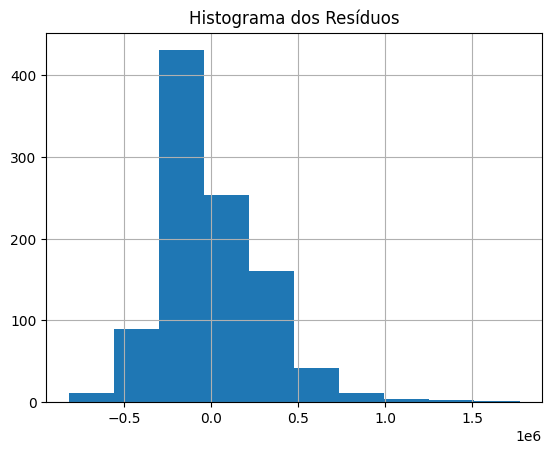

In [62]:
#RESIDUOS
modelo_0.resid.hist()
plt.title("Histograma dos Resíduos")
plt.show()

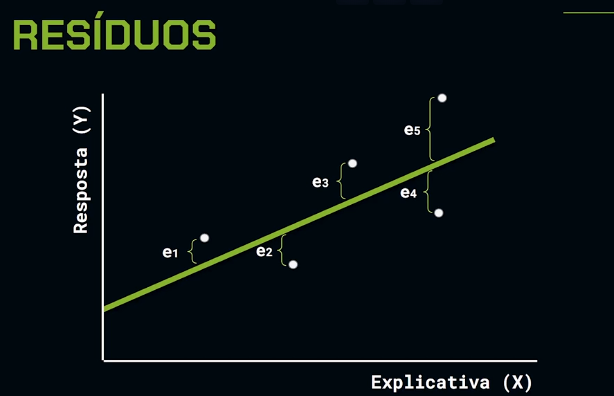

o resíduo é a distância vertical entre o ponto real (o que aconteceu de fato) e a linha de regressão (o que o seu modelo previu).Ponto acima da linha: O valor real foi maior que a previsão (resíduo positivo).Ponto abaixo da linha: O valor real foi menor que a previsão (resíduo negativo).A conta é simples: $Resíduo = Valor Real - Valor Previsto$

In [63]:
# AGORA vou usar os dados de teste pra ver se o modelo conseguiu aprender bem
# Eu tinha usado r² com os dados de treino agr to usando c o de teste p ver se ele acha um numero ~~
# definindo o y previsto
y_predict = modelo_0.predict(X_test)

#importando r2_score
from sklearn.metrics import r2_score
#printando o r²
print("R²: ", r2_score(y_test, y_predict))

R²:  0.38530928723202407
